In [1]:

from imgnet.query import ValidQuery
from imgnet.supported_collections import SUPPORTED_COLLECTIONS
import pandas as pd

# Modalities that RTSTRUCT can reference
RTSTRUCT_REFERENCE_MODALITIES = [
    "CT",   # Computed Tomography
    "MR",   # Magnetic Resonance
    "PT",   # Positron Emission Tomography
]

# Modalities that SEG can reference
SEG_REFERENCE_MODALITIES = [
    "CT",
    "MR",
    # SEG can technically reference any image-based series
]

modality_queries = [f"{ref},RTSTRUCT" for ref in RTSTRUCT_REFERENCE_MODALITIES] + [f"{ref},SEG" for ref in SEG_REFERENCE_MODALITIES]


col = {}
for collection in SUPPORTED_COLLECTIONS:
    print(f"processing: {collection}")
    col[collection] = ValidQuery(
        collections = collection,
        modalities = modality_queries #["CT,RTSTRUCT", "CT,SEG", "MR,RTSTRUCT", "MR,SEG"]
    ).process()
    print(f"processed: {collection}")
    

processing: CTpred-Sunitinib-panNET
processed: CTpred-Sunitinib-panNET
processing: TCGA-LUSC
processed: TCGA-LUSC
processing: TCGA-STAD
processed: TCGA-STAD
processing: LungCT-Diagnosis
processed: LungCT-Diagnosis
processing: MIDRC-RICORD-1B
processed: MIDRC-RICORD-1B
processing: MIDI-B-Curated-Validation
processed: MIDI-B-Curated-Validation
processing: RIDER PHANTOM PET-CT
processed: RIDER PHANTOM PET-CT
processing: Pelvic-Reference-Data
processed: Pelvic-Reference-Data
processing: Lung-Fused-CT-Pathology
processed: Lung-Fused-CT-Pathology
processing: MIDRC-RICORD-1C
processed: MIDRC-RICORD-1C
processing: CMB-MML
processed: CMB-MML
processing: CMB-PCA
processed: CMB-PCA
processing: Duke-Breast-Cancer-MRI
processed: Duke-Breast-Cancer-MRI
processing: TCGA-LIHC
processed: TCGA-LIHC
processing: Adrenal-ACC-Ki67-Seg
processed: Adrenal-ACC-Ki67-Seg
processing: NaF PROSTATE
processed: NaF PROSTATE
processing: GBM-DSC-MRI-DRO
processed: GBM-DSC-MRI-DRO
processing: PDMR-833975-119-R
processed

In [2]:
im_counts = {}
mask_counts = {}

for key in col:
    df = col[key]
    im_counts[key] = len(df[df["Modality"] == "CT"]) + len(df[df["Modality"] == "MR"])
    mask_counts[key] = len(df[df["Modality"] == "RTSTRUCT"]) + len(df[df["Modality"] == "SEG"])
    

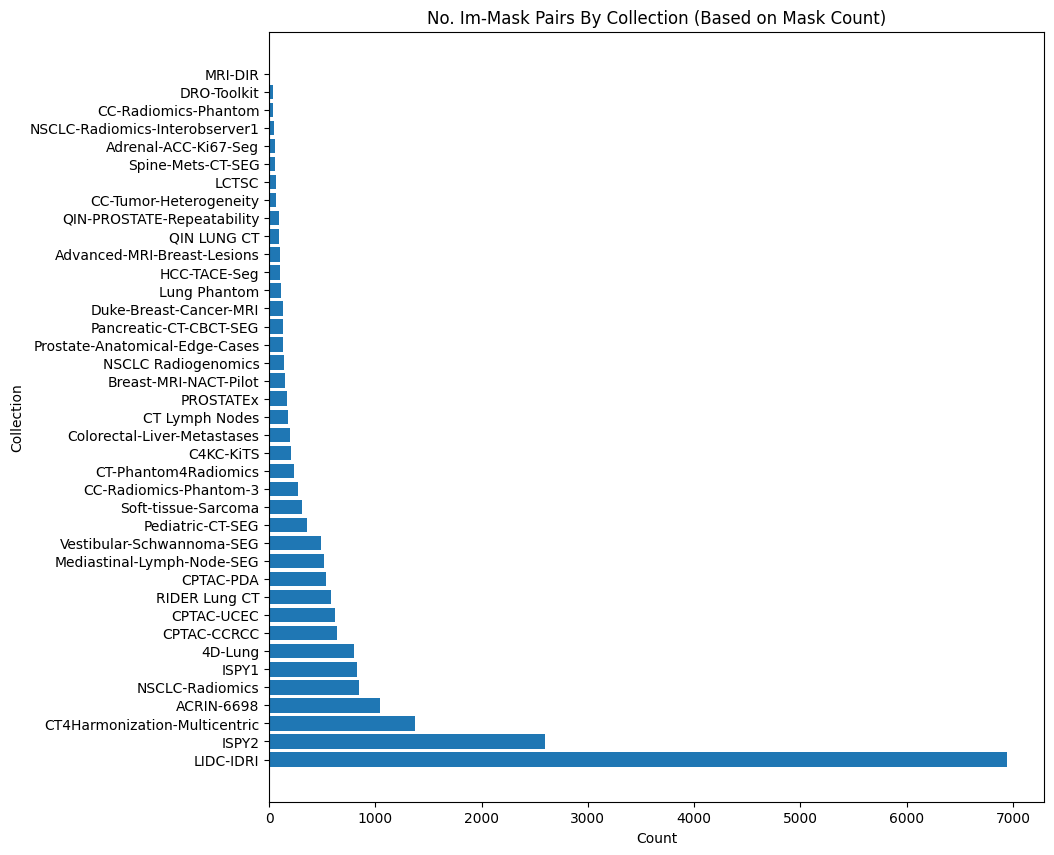

21243


In [3]:
import matplotlib.pyplot as plt

filtered_data = {k: v for k, v in mask_counts.items() if v != 0}
# Sort items by value (largest first)
sorted_items = sorted(filtered_data.items(), key=lambda x: x[1], reverse=True)
total = sum(filtered_data.values())
# Unpack into keys and values
keys, values = zip(*sorted_items)

# Plot
plt.figure(figsize=(10, 10))  # width=10, height=6
plt.barh(keys, values)
plt.xlabel("Count")
plt.ylabel("Collection")
plt.title("No. Im-Mask Pairs By Collection (Based on Mask Count)")

plt.show()

print(total)


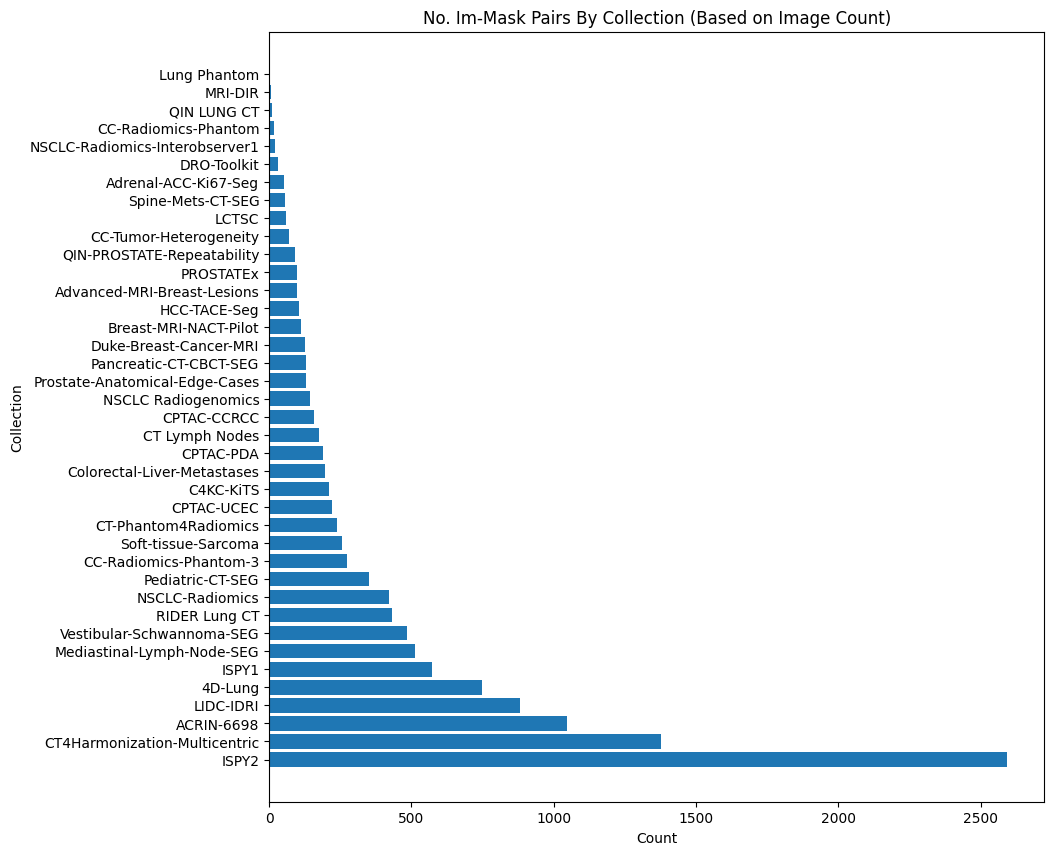

12704


In [4]:
filtered_data = {k: v for k, v in im_counts.items() if v != 0}
# Sort items by value (largest first)
sorted_items = sorted(filtered_data.items(), key=lambda x: x[1], reverse=True)

total = sum(filtered_data.values())

# Unpack into keys and values
keys, values = zip(*sorted_items)

# Plot
plt.figure(figsize=(10, 10))  # width=10, height=6
plt.barh(keys, values)
plt.xlabel("Count")
plt.ylabel("Collection")
plt.title("No. Im-Mask Pairs By Collection (Based on Image Count)")

plt.show()

print(total)